In [1]:

# from plotPipe import drawPipeline, createGraph, createLogicalDependencyGraph, createLogicalDependencyGraphOfNanoOps, createLogicalDependencyGraphOfLayeredNanoOps\
#     ,calcStartEndLayered,getCycleTime,drawPipelineLayered,createGraphOfLayeredNanoOps
from operation import Operation, NanoOperation, Dependency, LayeredOperation, NanoOperationSecondStage
from itertools import accumulate
from typing import Dict

hdim=8192
idim=14336*2
ngpu=8
hsplit = hdim // ngpu
isplit = idim // ngpu
kqv_n = int(hsplit * 1.5)

global_batch_size = 2048
decode_batch_size = 1280
prefill_batch_size = 768

In [2]:
batch_size_range = list(range(128, global_batch_size+1, 128))
# create operations
operations:list[Operation] = [
    Operation("KQV", 0, global_batch_size, [Dependency("AR_D", True)], "gemm", (kqv_n, hdim), batch_size_range),
    Operation("GEMV", 0, decode_batch_size, [Dependency("KQV")], "gemv", (0,0,0), batch_size_range),
    Operation("PF", decode_batch_size, prefill_batch_size, [Dependency("KQV")], "gemv", (0,0,0), batch_size_range),
    Operation("AG_GEMV", 0, global_batch_size, [Dependency("GEMV"), Dependency("PF")], "net", (hdim), batch_size_range),
    Operation("O", 0, global_batch_size, [Dependency("AG_GEMV")], "gemm", (hsplit, hdim), batch_size_range),
    Operation("O2", 0, global_batch_size, [Dependency("GEMV"), Dependency("PF")], "gemm", (hsplit, hdim), batch_size_range),
    Operation("AR_O", 0, global_batch_size, [Dependency("O2")], "net", (hdim), batch_size_range),
    Operation("AG_O", 0, global_batch_size, [Dependency("O")], "net", (hdim), batch_size_range),
    Operation("UG", 0, global_batch_size, [Dependency("AG_O"), Dependency("AR_O")], "gemm", (2*isplit, hdim), batch_size_range),
    Operation("D", 0, global_batch_size, [Dependency("UG")], "gemm", (hdim, isplit), batch_size_range),
    Operation("AR_D", 0, global_batch_size, [Dependency("D")], "net", (hdim), batch_size_range),
]

nano_operation_num_map = {
    "KQV": 4,
    "GEMV": 4,
    "PF": 1,
    "AG_GEMV": 2,
    "O": 1,
    "O2": 1,
    "AR_O": 1,
    "AG_O": 1,
    "UG": 2,
    "D": 2,
    "AR_D": 2,
}

for op in operations:
    op.nano_operations = []
    op.num_nano_batch = nano_operation_num_map[op.name]
    
# create a map from name to operation
operation_map = {}
for op in operations:
    operation_map[op.name] = op

for op in operations:
    op.depend_on_operations = []
    for dep in op.depends_on:
        if isinstance(dep, Dependency):
            op.depend_on_operations.append(Dependency(operation_map[dep.operation], dep.depend_on_previous_layer))

In [3]:
# read profile
from profileAnalysis import getAllReduceProfile, getAllgatherProfile, getGemmProfile

getGemmProfile((640, 1024, 8192), ("RowMajor", "RowMajor", "RowMajor"))


,M,N,K,cta_m,cta_n,cta_k,warp_m,warp_n,warp_k,split,stage,A_layout,B_layout,D_layout,time,GFLOPs,blocks,allSMTflops,tag
0,640,1024,8192,128,256,32,64,64,32,1,3,RowMajor,RowMajor,RowMajor,0.197054,54489.6,20.0,294243.84,128_256_32_64_64_32_1_3_RowMajor_RowMajor_RowM...
1,640,1024,8192,128,128,32,64,64,32,1,5,RowMajor,RowMajor,RowMajor,0.102480,104776.0,40.0,282895.20,128_128_32_64_64_32_1_5_RowMajor_RowMajor_RowM...
2,640,1024,8192,128,256,32,64,64,32,3,3,RowMajor,RowMajor,RowMajor,0.082161,130688.0,60.0,235238.40,128_256_32_64_64_32_3_3_RowMajor_RowMajor_RowM...
3,640,1024,8192,128,128,32,64,64,32,2,5,RowMajor,RowMajor,RowMajor,0.059951,179103.0,80.0,241789.05,128_128_32_64_64_32_2_5_RowMajor_RowMajor_RowM...
4,640,1024,8192,128,128,32,64,64,32,5,5,RowMajor,RowMajor,RowMajor,0.058306,184158.0,200.0,99445.32,128_128_32_64_64_32_5_5_RowMajor_RowMajor_RowM...


In [4]:
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from functools import lru_cache
import numpy as np
gemv_70b_perf = pd.read_csv("./trace/gemv_70B.csv")
gemv_8b_perf = pd.read_csv("./trace/gemv_8B.csv")

def getGemvTime(df_gemv, batch_size, seq_len):
    # 1. Sort and extract the two axes we care about
    df_sorted = df_gemv.sort_values(by=['batch_size', 'seqlen']).copy()
    batch_sizes = df_sorted['batch_size'].unique()
    seqlens     = df_sorted['seqlen'].unique()
    
    # 2. Reshape the measured times into a 2-D grid
    #    (assumes one sample per (batch, seq) pair in df_gemv)
    times = df_sorted['gemv_time'].values.reshape(
        len(batch_sizes),
        len(seqlens)
    )
    
    # 3. Build a 2-D interpolator
    interpolator = RegularGridInterpolator(
        (batch_sizes, seqlens),  # the grid points
        times,
        method='linear',
        bounds_error=False,      # allow extrapolation
        fill_value=None
    )
    
    # 4. Query at the new (batch_size, seq_len)
    pt = np.array([batch_size, seq_len])
    est = interpolator(pt)
    
    # 5. Return in milliseconds
    return est

def getGEMV8B(batch, seqlen):
    return getGemvTime(gemv_8b_perf, batch, seqlen)[0]
def getGEMV70B(batch, seqlen):
    return getGemvTime(gemv_70b_perf, batch, seqlen)[0]

In [5]:
print(getGEMV70B(1408, 1024))
print(getGEMV8B(341, 1280))

0.4833919694504374
1.0833180254496388


In [6]:
category_list = list(set([op.category for op in operations]))
category_op_map: dict[str, list[Operation]] = {}
for category in category_list:
    category_op_map[category] = []
for op in operations:
    category_op_map[op.category].append(op)

In [7]:
getGemmProfile((640, 1024, 8192), ("RowMajor", "RowMajor", "RowMajor"))

,M,N,K,cta_m,cta_n,cta_k,warp_m,warp_n,warp_k,split,stage,A_layout,B_layout,D_layout,time,GFLOPs,blocks,allSMTflops,tag
0,640,1024,8192,128,256,32,64,64,32,1,3,RowMajor,RowMajor,RowMajor,0.197054,54489.6,20.0,294243.84,128_256_32_64_64_32_1_3_RowMajor_RowMajor_RowM...
1,640,1024,8192,128,128,32,64,64,32,1,5,RowMajor,RowMajor,RowMajor,0.102480,104776.0,40.0,282895.20,128_128_32_64_64_32_1_5_RowMajor_RowMajor_RowM...
2,640,1024,8192,128,256,32,64,64,32,3,3,RowMajor,RowMajor,RowMajor,0.082161,130688.0,60.0,235238.40,128_256_32_64_64_32_3_3_RowMajor_RowMajor_RowM...
3,640,1024,8192,128,128,32,64,64,32,2,5,RowMajor,RowMajor,RowMajor,0.059951,179103.0,80.0,241789.05,128_128_32_64_64_32_2_5_RowMajor_RowMajor_RowM...
4,640,1024,8192,128,128,32,64,64,32,5,5,RowMajor,RowMajor,RowMajor,0.058306,184158.0,200.0,99445.32,128_128_32_64_64_32_5_5_RowMajor_RowMajor_RowM...


In [8]:
getAllgatherProfile(2048 * hdim // 1024 // 1024)

,size,blocks,time
0,16777216,8,0.11891


In [9]:

import math
for gemm_op in category_op_map["gemm"]:
    for batch_size in batch_size_range:
        df = getGemmProfile((batch_size, gemm_op.fixed_shape[0], gemm_op.fixed_shape[1]), ("RowMajor", "RowMajor", "RowMajor"))
        
            
        # get last row of the dataframe
        last_row = df.iloc[-1]
        if gemm_op.name == "KQV":
            gemm_op.duration_map[(batch_size, 1)] = last_row["time"] * 2
        else:
            gemm_op.duration_map[(batch_size, 1)] = last_row["time"]
            
        for i in range(1, 10, 2):
            p = i/10
            gemm_op.duration_map[(batch_size, p)] = gemm_op.duration_map[(batch_size, 1)] / p
        
gemv_interference_profile = pd.read_csv("./trace/gemv_interference.csv") # with columns R, P
gemv_r_p_map ={} 
# read the rp_map from the csv file
for index, row in gemv_interference_profile.iterrows():
    r = row["R"]
    p = row["P"]
    gemv_r_p_map[r] = p
    
for batch_size in batch_size_range:
    operation_map["GEMV"].duration_map[(batch_size, 1)] = getGEMV70B(batch_size, 1024)
    print(operation_map["GEMV"].duration_map[(batch_size, 1)])
    for r in gemv_r_p_map.keys():
        p = gemv_r_p_map[r]
        operation_map["GEMV"].duration_map[(batch_size, r)] = operation_map["GEMV"].duration_map[(batch_size, 1)] / p

for batch_size in batch_size_range:
    operation_map["PF"].duration_map[(batch_size, 1)] = 100/1000/ global_batch_size * batch_size
    for i in range(1, 10, 1):
        p = i/10
        operation_map["PF"].duration_map[(batch_size, p)] = 100/1000/ global_batch_size * batch_size * p

net_interference_profile = pd.read_csv("./trace/net_interference.csv") # with columns R, P
net_r_p_map ={}
# read the rp_map from the csv file
for index, row in net_interference_profile.iterrows():
    r = row["R"]
    p = row["P"]
    net_r_p_map[r] = p

for batch_size in batch_size_range:
    operation_map["AG_GEMV"].duration_map[(batch_size, 1)] = getAllgatherProfile(batch_size * hdim // 1024 // 1024*2).iloc[-1]["time"]
    operation_map["AG_O"].duration_map[(batch_size, 1)] = getAllgatherProfile(batch_size * hdim // 1024 // 1024*2).iloc[-1]["time"]
    operation_map["AR_D"].duration_map[(batch_size, 1)] = getAllReduceProfile(batch_size * hdim // 1024 // 1024*2).iloc[-1]["time"]
    operation_map["AR_O"].duration_map[(batch_size, 1)] = getAllReduceProfile(batch_size * hdim // 1024 // 1024*2).iloc[-1]["time"]
    for r in net_r_p_map.keys():
        p = net_r_p_map[r]
        operation_map["AG_GEMV"].duration_map[(batch_size, r)] = operation_map["AG_GEMV"].duration_map[(batch_size, 1)] / p
        operation_map["AG_O"].duration_map[(batch_size, r)] = operation_map["AG_O"].duration_map[(batch_size, 1)] / p
        operation_map["AR_D"].duration_map[(batch_size, r)] = operation_map["AR_D"].duration_map[(batch_size, 1)] / p
        operation_map["AR_O"].duration_map[(batch_size, r)] = operation_map["AR_O"].duration_map[(batch_size, 1)] / p


print("AG_GEMV", operation_map["AG_GEMV"].duration_map)


0.07520548996295
0.1155721935223
0.15593889708165
0.196305600641
0.237595018520975
0.27888443640095
0.320173854280925
0.3614632721609
0.4021061712574125
0.442749070353925
0.4833919694504374
0.52403486854695
0.5646777676434624
0.605320666739975
0.6459635658364874
0.6866064649329999
AG_GEMV {(128, 1): 0.030259999999999947, (128, 0.1): 0.07564999999999986, (128, 0.2): 0.05043333333333325, (128, 0.3): 0.04322857142857135, (128, 0.4): 0.03782499999999993, (128, 0.5): 0.033622222222222165, (256, 1): 0.04267999999999996, (256, 0.1): 0.10669999999999989, (256, 0.2): 0.07113333333333327, (256, 0.3): 0.06097142857142852, (256, 0.4): 0.053349999999999946, (256, 0.5): 0.04742222222222218, (384, 1): 0.05509999999999998, (384, 0.1): 0.13774999999999996, (384, 0.2): 0.09183333333333331, (384, 0.3): 0.0787142857142857, (384, 0.4): 0.06887499999999998, (384, 0.5): 0.0612222222222222, (512, 1): 0.06752, (512, 0.1): 0.16879999999999998, (512, 0.2): 0.11253333333333333, (512, 0.3): 0.09645714285714285, (5

In [10]:
# get layered operation
layer_num = 3
all_layered_ops: list[LayeredOperation] = []
op_to_layered_op_map: Dict[Operation, Dict[int,LayeredOperation]] = {}
for op in operations:
    for l in range(layer_num):
        layered_op = LayeredOperation(op, l)
        all_layered_ops.append(layered_op)
        if op not in op_to_layered_op_map:
            op_to_layered_op_map[op] = {}
        op_to_layered_op_map[op][l] = layered_op

for lop in all_layered_ops:
    lop.depend_on_operations = []
    count = 0
    for dep_op in lop.operation.depend_on_operations:
        if dep_op.depend_on_previous_layer:
            if lop.layer > 0:
                lop.depend_on_operations.append(op_to_layered_op_map[dep_op.operation][lop.layer-1])
        else:
            lop.depend_on_operations.append(op_to_layered_op_map[dep_op.operation][lop.layer])

In [11]:
# begin stage 1 from now on, use lop

min_start_batch = min([op.operation.start_batch for op in all_layered_ops])
max_end_batch = max([op.operation.start_batch + op.operation.batch_size for op in all_layered_ops])

# Fixed chunk size
chunk_size = 128

# Create global batch chunks
global_batch_chunks = list(range(min_start_batch, max_end_batch, chunk_size))

# Map operations to global chunks
for op in all_layered_ops:
    op.operation.batch_chunks = [c for c in global_batch_chunks if op.operation.start_batch <= c < op.operation.start_batch + op.operation.batch_size]


In [12]:
# create nanooperations
all_nano_ops: list[NanoOperation] = []
nano_op_map: Dict[LayeredOperation, Dict[int, NanoOperation]] = {}
for op in all_layered_ops:
    for i in range(op.operation.num_nano_batch):
        nano_op = NanoOperation(i, op)
        all_nano_ops.append(nano_op)
        if op not in nano_op_map:
            nano_op_map[op] = {}
        nano_op_map[op][i] = nano_op

In [13]:
import gurobipy as gp
from gurobipy import GRB
import itertools    
model = gp.Model("pipeline")
for nano_op in all_nano_ops:
    nano_op.initVariables(model) # add assign, batch_size, start_time, end_time, duration, batch_size_choice, num_chunks_assigned
    
# create sequantial constraints
sequence_nano = {}
category_nano_op_map: dict[str, list[NanoOperation]] = {}
for category in category_list:
    category_nano_op_map[category] = []
for nano_op in all_nano_ops:
    category_nano_op_map[nano_op.operation.category].append(nano_op)

for category in category_list:
    nano_ops = category_nano_op_map[category]
    for op_1, op_2 in itertools.combinations(nano_ops, 2):
        sequence_nano[op_1, op_2] = model.addVar(vtype=GRB.BINARY, name=f"{op_1.name}_before_{op_2.name}")

overlap_chunk = {}
# overlap chunk constraints
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        overlap_chunk[op1, op2] = model.addVar(vtype=GRB.BINARY, name=f"{op1.name}_overlap_chunk_with_{op2.name}")
    
C_max = model.addVar(vtype=GRB.CONTINUOUS, name="C_max")

Set parameter Username
Set parameter LicenseID to value 2586842
Academic license - for non-commercial use only - expires 2025-11-19


In [14]:
for nano_op in all_nano_ops:
    nano_op.addInternalConstraints(model, chunk_size)

In [15]:
# nanobatch partitions lop input
for lop in all_layered_ops:
    if lop.operation.name in ["AG_GEMV", "O", "O2", "AR_O", "AG_O"]:
        continue
    for c in lop.operation.batch_chunks:
        nano_op_list = nano_op_map[lop].values()
        model.addConstr(gp.quicksum([nano_op.assign[c] for nano_op in nano_op_list]) == 1, 
                        name=f"partition_{lop.name}_nano_{c}")
        print(f"partition_{lop.name}_nano_{c}")

partition_KQV_0_nano_0
partition_KQV_0_nano_128
partition_KQV_0_nano_256
partition_KQV_0_nano_384
partition_KQV_0_nano_512
partition_KQV_0_nano_640
partition_KQV_0_nano_768
partition_KQV_0_nano_896
partition_KQV_0_nano_1024
partition_KQV_0_nano_1152
partition_KQV_0_nano_1280
partition_KQV_0_nano_1408
partition_KQV_0_nano_1536
partition_KQV_0_nano_1664
partition_KQV_0_nano_1792
partition_KQV_0_nano_1920
partition_KQV_1_nano_0
partition_KQV_1_nano_128
partition_KQV_1_nano_256
partition_KQV_1_nano_384
partition_KQV_1_nano_512
partition_KQV_1_nano_640
partition_KQV_1_nano_768
partition_KQV_1_nano_896
partition_KQV_1_nano_1024
partition_KQV_1_nano_1152
partition_KQV_1_nano_1280
partition_KQV_1_nano_1408
partition_KQV_1_nano_1536
partition_KQV_1_nano_1664
partition_KQV_1_nano_1792
partition_KQV_1_nano_1920
partition_KQV_2_nano_0
partition_KQV_2_nano_128
partition_KQV_2_nano_256
partition_KQV_2_nano_384
partition_KQV_2_nano_512
partition_KQV_2_nano_640
partition_KQV_2_nano_768
partition_KQV_2

In [16]:
# AG_GEMV have same batch chunk selection with O, and AG_O
for lop in all_layered_ops:
    if lop.operation.name == "AG_GEMV":
        nano_op_list = nano_op_map[lop].values()
        corresponding_layerop = op_to_layered_op_map[operation_map["O"]][lop.layer]
        corresponding_op_list = nano_op_map[corresponding_layerop].values()
        corresponding_layerop2 = op_to_layered_op_map[operation_map["AG_O"]][lop.layer]
        corresponding_op_list2 = nano_op_map[corresponding_layerop2].values()
        for c in lop.operation.batch_chunks:
            model.addConstr(gp.quicksum([nano_op.assign[c] for nano_op in nano_op_list]) == 
                            gp.quicksum([nano_op.assign[c] for nano_op in corresponding_op_list]), 
                            name=f"same_batch_chunk_{lop.name}_nano_{c}")
            model.addConstr(gp.quicksum([nano_op.assign[c] for nano_op in nano_op_list]) ==
                            gp.quicksum([nano_op.assign[c] for nano_op in corresponding_op_list2]), 
                            name=f"same_batch_chunk_{lop.name}_nano_{c}_2")
# AR_O have same batch chunk selection with O2
for lop in all_layered_ops:
    if lop.operation.name == "AR_O":
        nano_op_list = nano_op_map[lop].values()
        corresponding_layerop = op_to_layered_op_map[operation_map["O2"]][lop.layer]
        corresponding_op_list = nano_op_map[corresponding_layerop].values()
        for c in lop.operation.batch_chunks:
            model.addConstr(gp.quicksum([nano_op.assign[c] for nano_op in nano_op_list]) == 
                            gp.quicksum([nano_op.assign[c] for nano_op in corresponding_op_list]), 
                            name=f"same_batch_chunk_{lop.name}_nano_{c}")


In [17]:
# O and O2 add up making all chunks selected
for lop in all_layered_ops:
    if lop.operation.name in ["O"]:
        nano_op_list = nano_op_map[lop].values()
        corresponding_layerop = op_to_layered_op_map[operation_map["O2"]][lop.layer]
        corresponding_op_list = nano_op_map[corresponding_layerop].values()
        for c in lop.operation.batch_chunks:
            model.addConstr(gp.quicksum([nano_op.assign[c] for nano_op in nano_op_list]) + 
                            gp.quicksum([nano_op.assign[c] for nano_op in corresponding_op_list]) == 1, 
                            name=f"add_up_{lop.name}_nano_{c}")

In [18]:
M = 1e6
# non-overlapping constraints
for type_name, nano_op_list in category_nano_op_map.items():
    for op1, op2 in itertools.combinations(nano_op_list, 2):
        model.addConstr(op1.end_time <= op2.start_time + 50 * (1 - sequence_nano[op1, op2]),
                        name=f"non_overlap_{op1.name}_{op2.name}_when_sequence_nano_1")
        model.addConstr(op2.end_time <= op1.start_time + 50 * sequence_nano[op1, op2],
                        name=f"non_overlap_{op1.name}_{op2.name}_when_sequence_nano_2")

In [19]:
# # detect overlap chunk
# for op1 in all_nano_ops:
#     for op2 in all_nano_ops:
#         if op1 == op2:
#             continue
#         common_chunks = set(op1.operation.batch_chunks).intersection(set(op2.operation.batch_chunks))
#         if common_chunks:
#             model.addConstr(overlap_chunk[op1, op2] >= gp.quicksum(op1.assign[c] * op2.assign[c] for c in common_chunks) / len(common_chunks),
#                             name=f"overlap_chunk_{op1.name}_{op2.name}")
#         else:
#             model.addConstr(overlap_chunk[op1, op2] == 0,
#                             name=f"overlap_chunk_{op1.name}_{op2.name}")

In [20]:
# Detect overlap chunk using link variables
link_assign = {}
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        common_chunks = set(op1.operation.batch_chunks).intersection(set(op2.operation.batch_chunks))
        if common_chunks:
            # Create link variables for each common chunk
            for c in common_chunks:
                link_var_name = f"link_{op1.name}_{op2.name}_{c}"
                link_assign[op1, op2, c] = model.addVar(vtype=GRB.BINARY, name=link_var_name)
                
                # Constraints to linearize the product op1.assign[c] * op2.assign[c]
                model.addConstr(link_assign[op1, op2, c] <= op1.assign[c], name=f"link_constr1_{link_var_name}")
                model.addConstr(link_assign[op1, op2, c] <= op2.assign[c], name=f"link_constr2_{link_var_name}")
                model.addConstr(link_assign[op1, op2, c] >= op1.assign[c] + op2.assign[c] - 1, name=f"link_constr3_{link_var_name}")
            
            # Overlap chunk constraint using link variables
            model.addConstr(
                overlap_chunk[op1, op2] >= gp.quicksum(link_assign[op1, op2, c] for c in common_chunks) / len(common_chunks),
                name=f"overlap_chunk_{op1.name}_{op2.name}")
        else:
            model.addConstr(
                overlap_chunk[op1, op2] == 0,
                name=f"overlap_chunk_{op1.name}_{op2.name}")


In [21]:
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        if op2.layered_operation in op1.layered_operation.depend_on_operations:
            model.addConstr(op1.start_time >= op2.end_time - 50 * (1 - overlap_chunk[op1, op2]),
                            name=f"overlap_chunk_{op1.name}_{op2.name}_when_depend_on")

In [22]:
for op1, op2 in itertools.combinations(all_nano_ops, 2):
    if op1 == op2:
        continue
    if op1.operation == op2.operation and op1.idx == op2.idx: # only different by the layer
        for c in op1.operation.batch_chunks:
            model.addConstr(op1.assign[c] == op2.assign[c] , name=f"same_nano_same_assignment{op1.name}_{op2.name}")

In [23]:
for op in all_nano_ops:
    model.addConstr(C_max >= op.end_time, name=f"update_C_max_{op.name}")

In [24]:
# O, AG_O, UG, D should have same nano batch partition
idx_map = {0:[], 1:[]}
for lop in all_nano_ops:
    if lop.operation.name in ["UG", "D"]:
        idx_map[lop.idx].append(lop)
for idx, lop_list in idx_map.items():
    for op1, op2 in itertools.combinations(lop_list, 2):
        for c in op1.operation.batch_chunks:
            model.addConstr(op1.assign[c] == op2.assign[c], name=f"same_nano_same_assignment_across_{op1.name}_{op2.name}")

In [25]:
model.setObjective(C_max, GRB.MINIMIZE)
model.setParam("Threads", 200)
model.setParam("MIPFocus", 1)
model.setParam("TimeLimit", 60)
model.optimize()

Set parameter Threads to value 200
Set parameter MIPFocus to value 1
Set parameter TimeLimit to value 60
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 9554 64-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 128 physical cores, 256 logical processors, using up to 200 threads

Non-default parameters:
TimeLimit  60
MIPFocus  1
Threads  200

Optimize a model with 159757 rows, 57466 columns and 422475 nonzeros
Model fingerprint: 0xb7ec7dad
Variable types: 253 continuous, 57213 integer (57213 binary)
Coefficient statistics:
  Matrix range     [6e-03, 2e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+01]
Presolve removed 148630 rows and 52424 columns
Presolve time: 2.86s
Presolved: 11127 rows, 5042 columns, 31694 nonzeros
Variable types: 124 continuous, 4918 integer (4918 binary)
Performing another presolve...
Presolve removed 9334 rows and 3134 columns
Presolve

In [26]:
def nanobatch_num_to_str(num_map):
    return "_".join([f"{k}_{v}" for k, v in num_map.items()])

In [27]:
model.write(f"{nanobatch_num_to_str(nano_operation_num_map)}.sol")
model.write(f"{nanobatch_num_to_str(nano_operation_num_map)}.prm")
model.write(f"{nanobatch_num_to_str(nano_operation_num_map)}.lp")


In [28]:
model.write(f"final.sol")
model.write(f"final.prm")
model.write(f"final.lp")

In [29]:
# print durations
for op in all_nano_ops:
    print(op)

KQV_0_0 start: 0.418 end: 0.504 duration: 0.086 batch_size: 256 batch_size_choice: 256 chunk_id: 384 640
KQV_0_1 start: 0.155 end: 0.255 duration: 0.100 batch_size: 384 batch_size_choice: 384 chunk_id: 256 512 1152
KQV_0_2 start: 0.000 end: 0.155 duration: 0.155 batch_size: 640 batch_size_choice: 640 chunk_id: 0 128 768 896 1024
KQV_0_3 start: 0.255 end: 0.417 duration: 0.162 batch_size: 768 batch_size_choice: 768 chunk_id: 1280 1408 1536 1664 1792 1920
KQV_1_0 start: 2.273 end: 2.359 duration: 0.086 batch_size: 256 batch_size_choice: 256 chunk_id: 384 640
KQV_1_1 start: 2.578 end: 2.679 duration: 0.100 batch_size: 384 batch_size_choice: 384 chunk_id: 256 512 1152
KQV_1_2 start: 2.424 end: 2.578 duration: 0.155 batch_size: 640 batch_size_choice: 640 chunk_id: 0 128 768 896 1024
KQV_1_3 start: 2.728 end: 2.890 duration: 0.162 batch_size: 768 batch_size_choice: 768 chunk_id: 1280 1408 1536 1664 1792 1920
KQV_2_0 start: 4.620 end: 4.706 duration: 0.086 batch_size: 256 batch_size_choice: 2

KQV_0_0 start: 0.156 end: 0.212 duration: 0.0557 batch_size: 256 batch_size_choice: 256 chunk_id: 128 256
KQV_0_1 start: 0.0 end: 0.156 duration: 0.156 batch_size: 768 batch_size_choice: 768 chunk_id: 0 384 512 640 768 896
KQV_1_0 start: 1.13 end: 1.27 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
KQV_1_1 start: 1.86 end: 1.94 duration: 0.0839 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_2_0 start: 3.59 end: 3.67 duration: 0.0839 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_2_1 start: 2.86 end: 3.0 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
GEMV_0_0 start: 0.274 end: 1.27 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
GEMV_1_0 start: 1.94 end: 2.94 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
GEMV_2_0 start: 3.67 end: 4.67 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
PF_0_0 start: 0.156 end: 0.219 duration: 0.0625 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
PF_1_0 start: 1.5 end: 1.56 duration: 0.0625 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
PF_2_0 start: 3.0 end: 3.06 duration: 0.0625 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
O_0_0 start: 0.219 end: 0.307 duration: 0.0887 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
O_0_1 start: 1.27 end: 1.33 duration: 0.0561 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
O_1_0 start: 1.94 end: 2.03 duration: 0.0887 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
O_1_1 start: 3.0 end: 3.05 duration: 0.0561 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
O_2_0 start: 4.67 end: 4.72 duration: 0.0561 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
O_2_1 start: 3.67 end: 3.76 duration: 0.0887 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_0_0 start: 0.307 end: 0.863 duration: 0.555 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_0_1 start: 1.33 end: 1.68 duration: 0.356 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
UG_1_0 start: 2.03 end: 2.59 duration: 0.555 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_1_1 start: 3.05 end: 3.41 duration: 0.356 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
UG_2_0 start: 3.76 end: 4.31 duration: 0.555 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_2_1 start: 4.72 end: 5.08 duration: 0.356 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_0_0 start: 1.68 end: 1.86 duration: 0.177 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_0_1 start: 0.863 end: 1.13 duration: 0.27 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
D_1_0 start: 3.41 end: 3.59 duration: 0.177 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_1_1 start: 2.59 end: 2.86 duration: 0.27 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
D_2_0 start: 5.08 end: 5.25 duration: 0.177 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_2_1 start: 4.31 end: 4.58 duration: 0.27 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896

In [30]:
# # print all overlap variables in a 2D matrix
# for op1 in all_nano_ops:
#     for op2 in all_nano_ops:
#         if op1 == op2:
#             continue
#         if overlap_chunk[op1, op2].x > 0.5:
#             print(f"{op1.name} overlaps with {op2.name}")

In [31]:
# for op1 in all_nano_ops:
# for op2 in all_nano_ops:
#     if op1 == op2:
#         continue
#     if op2.layered_operation in op1.layered_operation.depend_on_operations:
#         print(f"{op1.name} depend on {op2.name}")
#         model.addConstr(op1.start_time >= op2.end_time - M * (1 - overlap_chunk[op1, op2]),
#                         name=f"overlap_chunk_{op1.name}_{op2.name}_when_depend_on")
# verify the solution
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        if op2.layered_operation in op1.layered_operation.depend_on_operations and overlap_chunk[op1, op2].x > 0.5:
            if op1.start_time.x <= op2.end_time.x - 0.001:
                print(f"overlap chunk between {op1.name} and {op2.name} is not correct")
            # else:
            #     print(f"overlap chunk between {op1.name} and {op2.name} is correct")

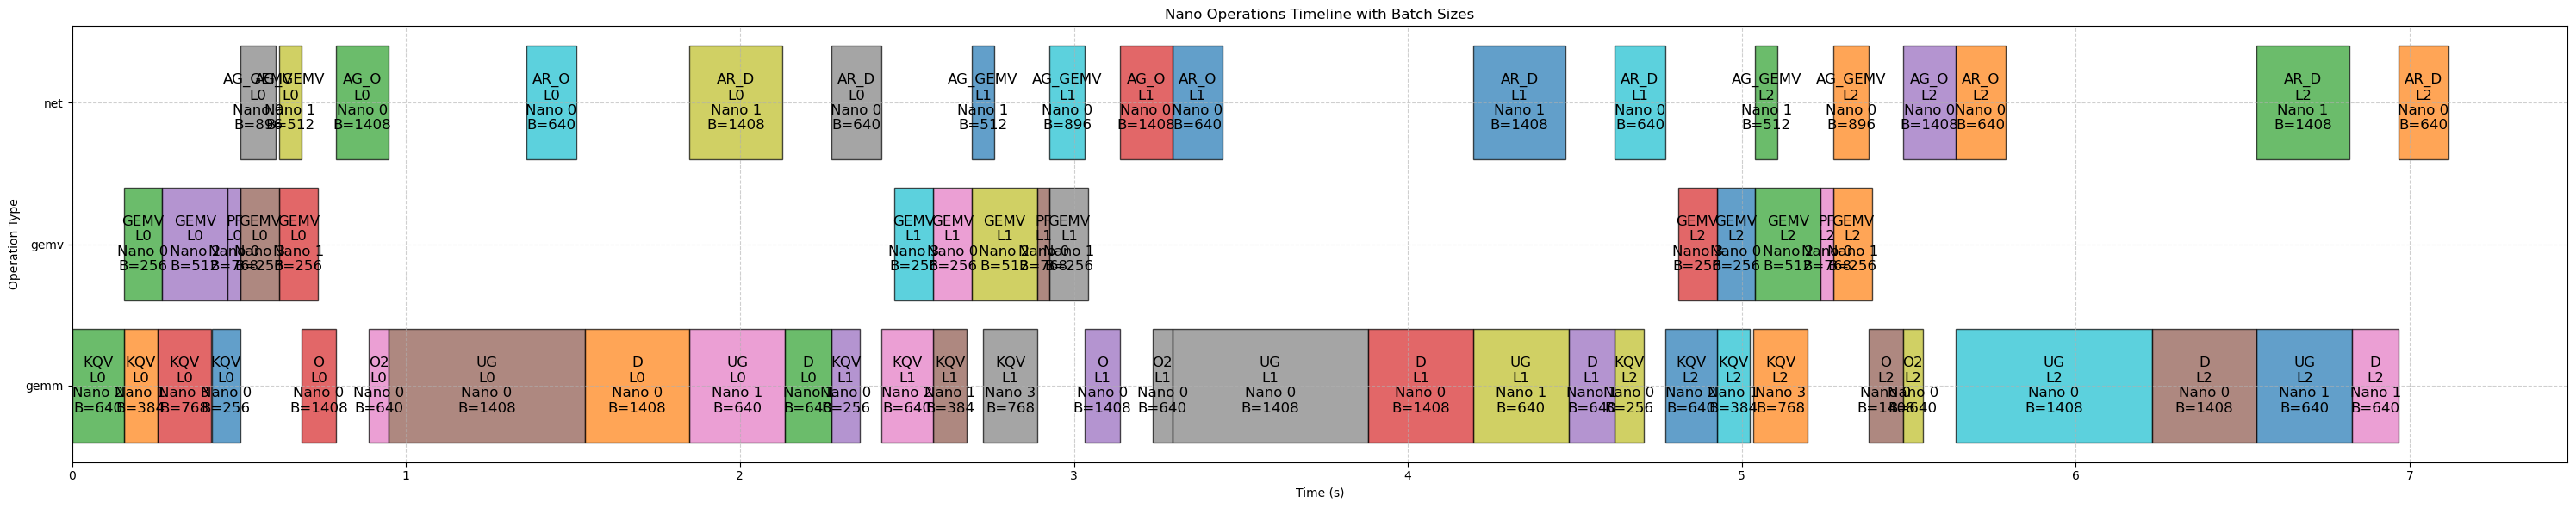

In [32]:
from matplotlib import pyplot as plt

# Assuming you have a list of NanoOperation instances called nano_operations_list
# and each NanoOperation has the required attributes.

# Extract unique operation types
operation_types = sorted(set(n.operation.category for n in all_nano_ops))
y_positions = {op_type: i for i, op_type in enumerate(operation_types)}

fig, ax = plt.subplots(figsize=(30, 6))

for n in all_nano_ops:
    n_name = n.name
    # Access the optimized values of the variables
    start_time = n.start_time.X
    duration = n.duration.X
    batch_size = n.batch_size.X
    op_type = n.operation.category  # Assuming 'category' is the type

    y_position = y_positions[op_type]
    
    # Plot the operation as a horizontal bar
    ax.barh(y_position, duration, left=start_time, height=0.8, alpha=0.7, edgecolor="black")
    
    # Annotate with operation name and batch size
    label = f"{n.operation.name}\nL{n.layered_operation.layer}\nNano {n.idx}\nB={int(batch_size)}"
    ax.text(start_time + duration / 2, y_position, label, ha="center", va="center", color="black", fontsize=12)

# Set y-ticks and labels
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Operation Type")
ax.set_title("Nano Operations Timeline with Batch Sizes")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("nano_operations_timeline.png")
plt.show()


In [33]:
# Extract dependencies
second_stage_nano_ops: list[NanoOperationSecondStage]= []
nano_op_to_second_stage_map: Dict[NanoOperation, NanoOperationSecondStage] = {}

# Create NanoOperationSecondStage instances
for op1 in all_nano_ops:
    new_op = NanoOperationSecondStage(op1)
    second_stage_nano_ops.append(new_op)
    nano_op_to_second_stage_map[op1] = new_op

# Set up logical dependencies
for op1 in all_nano_ops:
    new_op = nano_op_to_second_stage_map[op1]
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        if op2.layered_operation in op1.layered_operation.depend_on_operations:
            if overlap_chunk[op1, op2].X > 0.5:
                dep_second_stage_op = nano_op_to_second_stage_map[op2]
                new_op.depend_on_nano_ops_logical.append(dep_second_stage_op)
                
# Apply stream dependencies
for type_name, list_nano_op in category_nano_op_map.items():
    # sort list_nano_op by start time
    list_nano_op.sort(key=lambda x: x.start_time.X)
    for op1, op2 in zip(list_nano_op[:-1], list_nano_op[1:]):
        nano_op_to_second_stage_map[op2].depend_on_nano_ops_stream.append(nano_op_to_second_stage_map[op1])

for op in second_stage_nano_ops:
    print(op)


KQV_0_0 batch_size: 256
   -> KQV_0_3
KQV_0_1 batch_size: 384
   -> KQV_0_2
KQV_0_2 batch_size: 640
KQV_0_3 batch_size: 768
   -> KQV_0_1
KQV_1_0 batch_size: 256
   -> AR_D_0_1
   -> D_0_1
KQV_1_1 batch_size: 384
   -> AR_D_0_0
   -> AR_D_0_1
   -> KQV_1_2
KQV_1_2 batch_size: 640
   -> AR_D_0_0
   -> AR_D_0_1
   -> KQV_1_0
KQV_1_3 batch_size: 768
   -> AR_D_0_0
   -> AR_D_0_1
   -> KQV_1_1
KQV_2_0 batch_size: 256
   -> AR_D_1_1
   -> D_1_1
KQV_2_1 batch_size: 384
   -> AR_D_1_0
   -> AR_D_1_1
   -> KQV_2_2
KQV_2_2 batch_size: 640
   -> AR_D_1_0
   -> AR_D_1_1
   -> KQV_2_0
KQV_2_3 batch_size: 768
   -> AR_D_1_0
   -> AR_D_1_1
   -> KQV_2_1
GEMV_0_0 batch_size: 256
   -> KQV_0_2
GEMV_0_1 batch_size: 256
   -> KQV_0_2
   -> GEMV_0_3
GEMV_0_2 batch_size: 512
   -> KQV_0_1
   -> KQV_0_2
   -> GEMV_0_0
GEMV_0_3 batch_size: 256
   -> KQV_0_0
   -> PF_0_0
GEMV_1_0 batch_size: 256
   -> KQV_1_2
   -> GEMV_1_3
GEMV_1_1 batch_size: 256
   -> KQV_1_2
   -> PF_1_0
GEMV_1_2 batch_size: 512
   -> KQ

In [34]:
import importlib
import operation
importlib.reload(operation)
from operation import NanoOperationSecondStage

def second_stage_search(time_unit):

    # Compute the time horizon based on the maximum possible end time
    max_end_time = max(op.end_time.X for op in all_nano_ops)
    max_duration = max(
        max(op.duration_map.values()) for op in second_stage_nano_ops
    )
    time_horizon = int(20 // time_unit )
    print(int((max_end_time + max_duration) / time_unit) + 1)
    print(f"Time horizon: {time_horizon}")

    from operation import NanoOperationSecondStage
    # Create the second stage model
    second_stage_model = gp.Model("SecondStageOptimization")

    # Initialize variables and constraints for each NanoOperationSecondStage
    for op in second_stage_nano_ops:
        op.initVariables(second_stage_model, time_unit, time_horizon)
    for op in second_stage_nano_ops:
        for p in op.p_choices:
            op.p_vars[p].Start = 0.0
        if op.operation.category == "gemm" and op.operation.name == "KQV" or op.operation.name == "O":
            op.p_vars[0.3].Start = 1
        elif op.operation.category == "gemm":
            op.p_vars[0.9].Start = 1
        elif op.operation.category == "net":
            op.p_vars[0.1].Start = 1
        elif op.operation.category == "gemv":
            op.p_vars[0.6].Start = 1
    # Add constraints for each operation
    for op in second_stage_nano_ops:
        op.addConstraints(second_stage_model, time_unit, time_horizon)

    for time_index in range(time_horizon + 1):
        utilization_terms = []
        for op in second_stage_nano_ops:
            for p_value in op.p_choices:
                utilization_terms.append(p_value * op.isrunning[p_value, time_index])
        # Add resource constraint at time_index
        second_stage_model.addConstr(
            gp.quicksum(utilization_terms) <= 1,
            name=f'gpu_utilization_at_time_{time_index}'
        )

    # Dependency constraints
    for op in second_stage_nano_ops:
        for dep_op in op.depend_on_nano_ops:
            # Successor start time >= Predecessor end time
            second_stage_model.addConstr(
                op.start_time_units >= dep_op.end_time_units,
                name=f'dependency_{dep_op.name}_{op.name}'
            )

    # Makespan constraints
    C_max = second_stage_model.addVar(vtype=GRB.CONTINUOUS, name='C_max')
    for op in second_stage_nano_ops:
        second_stage_model.addConstr(
            C_max >= op.end_time_units,
            name=f'makespan_constraint_{op.name}'
        )

    # simpify: across layer, p selection is the same
    for op1, op2 in itertools.combinations(second_stage_nano_ops, 2):
        if op1 == op2:
            continue
        if op1.operation == op2.operation and op1.idx == op2.idx: # only different by the layer
            for p in op1.p_choices:
                second_stage_model.addConstr(op1.p_vars[p] == op2.p_vars[p] , name=f"same_p_same_assignment{op1.name}_{op2.name}")
                
    # Objective: Minimize makespan
    second_stage_model.setObjective(C_max, GRB.MINIMIZE)
    # Optimize the model
    second_stage_model.setParam("Threads", 200)
    second_stage_model.setParam("MIPFocus", 1)
    # second_stage_model.setParam("Heuristics", 0.1)
    
    second_stage_model.optimize()
    # if at least one solution was found
    if second_stage_model.status in {GRB.OPTIMAL, GRB.SUBOPTIMAL}:
        print(f"Second stage model solved in {second_stage_model.Runtime} seconds")
        for op in second_stage_nano_ops:
            op.solved = True
            op.saved_p_var_x = {p: op.p_vars[p].X for p in op.p_choices}
    return second_stage_model, time_unit



In [35]:

second_stage_model, time_unit = second_stage_search(0.2)
# second_stage_model, time_unit = second_stage_search(0.1)

# second_stage_model, time_unit = second_stage_search(0.08)
# second_stage_model, time_unit = second_stage_search(0.04)
# # figureout why infeasible
# second_stage_model.computeIIS()
# for c in second_stage_model.getConstrs():
#     if c.IISConstr:
#         print(f"Infeasible Constraint: {c.constrName}")
# second_stage_model, time_unit = second_stage_search(0.04)


79
Time horizon: 99
Set parameter Threads to value 200
Set parameter MIPFocus to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: AMD EPYC 9554 64-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 128 physical cores, 256 logical processors, using up to 200 threads

Non-default parameters:
MIPFocus  1
Threads  200

Optimize a model with 132718 rows, 44365 columns and 353148 nonzeros
Model fingerprint: 0xd56a933a
Variable types: 1 continuous, 44364 integer (44238 binary)
Coefficient statistics:
  Matrix range     [1e-01, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

User MIP start produced solution with objective 82 (0.75s)
Loaded user MIP start with objective 82

Presolve removed 26913 rows and 6388 columns (presolve time = 5s)...
Presolve removed 26913 rows and 6388 columns (presolve time = 10s)...
Presolve removed 26913 rows and 6388 columns (presolve

In [36]:
# Extract the schedule and print results
if second_stage_model.status in [GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.INTERRUPTED]:
    total_makespan = C_max.X
    print(f'\nOptimal total runtime (makespan): {total_makespan}')
    print('\nOperation Schedule:')
    schedule = {}
    for op in second_stage_nano_ops:
        p_value = sum([p_value * op.p_vars[p_value].X for p_value in op.p_choices])
        duration = op.duration_units[p_value] * time_unit
        start_time = op.start_time_units.X * time_unit
        finish_time = op.end_time_units.X * time_unit
        schedule[op] = {
            'start_time': start_time,
            'gpu_utilization': p_value,
            'duration': duration,
            'finish_time': finish_time
        }
        print(f'{op.name} starts {start_time:.3f} end {start_time + duration:.3f} p {p_value}, duration {duration}')

    
else:
    print('No feasible solution found.')


Optimal total runtime (makespan): 7.116173375200506

Operation Schedule:
KQV_0_0 starts 1.000 end 1.200 p 0.5, duration 0.2
KQV_0_1 starts 0.200 end 0.600 p 0.3, duration 0.4
KQV_0_2 starts -0.000 end 0.200 p 0.9, duration 0.2
KQV_0_3 starts 0.600 end 0.800 p 0.9, duration 0.2
KQV_1_0 starts 3.800 end 4.000 p 0.5, duration 0.2
KQV_1_1 starts 4.200 end 4.600 p 0.3, duration 0.4
KQV_1_2 starts 4.000 end 4.200 p 0.9, duration 0.2
KQV_1_3 starts 4.800 end 5.000 p 0.9, duration 0.2
KQV_2_0 starts 7.600 end 7.800 p 0.5, duration 0.2
KQV_2_1 starts 8.000 end 8.400 p 0.3, duration 0.4
KQV_2_2 starts 7.800 end 8.000 p 0.9, duration 0.2
KQV_2_3 starts 8.600 end 8.800 p 0.9, duration 0.2
GEMV_0_0 starts 0.400 end 0.600 p 0.4, duration 0.2
GEMV_0_1 starts 1.400 end 1.600 p 0.4, duration 0.2
GEMV_0_2 starts 0.800 end 1.000 p 1.0, duration 0.2
GEMV_0_3 starts 1.200 end 1.400 p 0.5, duration 0.2
GEMV_1_0 starts 4.400 end 4.600 p 0.4, duration 0.2
GEMV_1_1 starts 5.200 end 5.400 p 0.4, duration 0.2
G

In [37]:
for time_index in range(100):
    utilization_terms = []
    runninglist = []
    for op in second_stage_nano_ops:
        for p_value in op.p_choices:
            utilization_terms.append(p_value * op.isrunning[p_value, time_index].x)
            if op.isrunning[p_value, time_index].x > 0:
                runninglist.append((op.name, p_value))
                print(f'{op.name} running at time {time_index} with p {p_value}')
    print(f'gpu utilization at time {time_index}: {sum(utilization_terms)}')    
    print(f'running list at time {time_index}: {runninglist}')

KQV_0_2 running at time 0 with p 0.9
gpu utilization at time 0: 0.9
running list at time 0: [('KQV_0_2', 0.9)]
KQV_0_1 running at time 1 with p 0.3
gpu utilization at time 1: 0.3
running list at time 1: [('KQV_0_1', 0.3)]
KQV_0_1 running at time 2 with p 0.3
GEMV_0_0 running at time 2 with p 0.4
gpu utilization at time 2: 0.7
running list at time 2: [('KQV_0_1', 0.3), ('GEMV_0_0', 0.4)]
KQV_0_3 running at time 3 with p 0.9
gpu utilization at time 3: 0.9
running list at time 3: [('KQV_0_3', 0.9)]
GEMV_0_2 running at time 4 with p 1
gpu utilization at time 4: 1.0
running list at time 4: [('GEMV_0_2', 1)]
KQV_0_0 running at time 5 with p 0.5
PF_0_0 running at time 5 with p 0.4
gpu utilization at time 5: 0.9
running list at time 5: [('KQV_0_0', 0.5), ('PF_0_0', 0.4)]
GEMV_0_3 running at time 6 with p 0.5
AG_GEMV_0_0 running at time 6 with p 0.3
gpu utilization at time 6: 0.8
running list at time 6: [('GEMV_0_3', 0.5), ('AG_GEMV_0_0', 0.3)]
GEMV_0_1 running at time 7 with p 0.4
AG_GEMV_0_1 

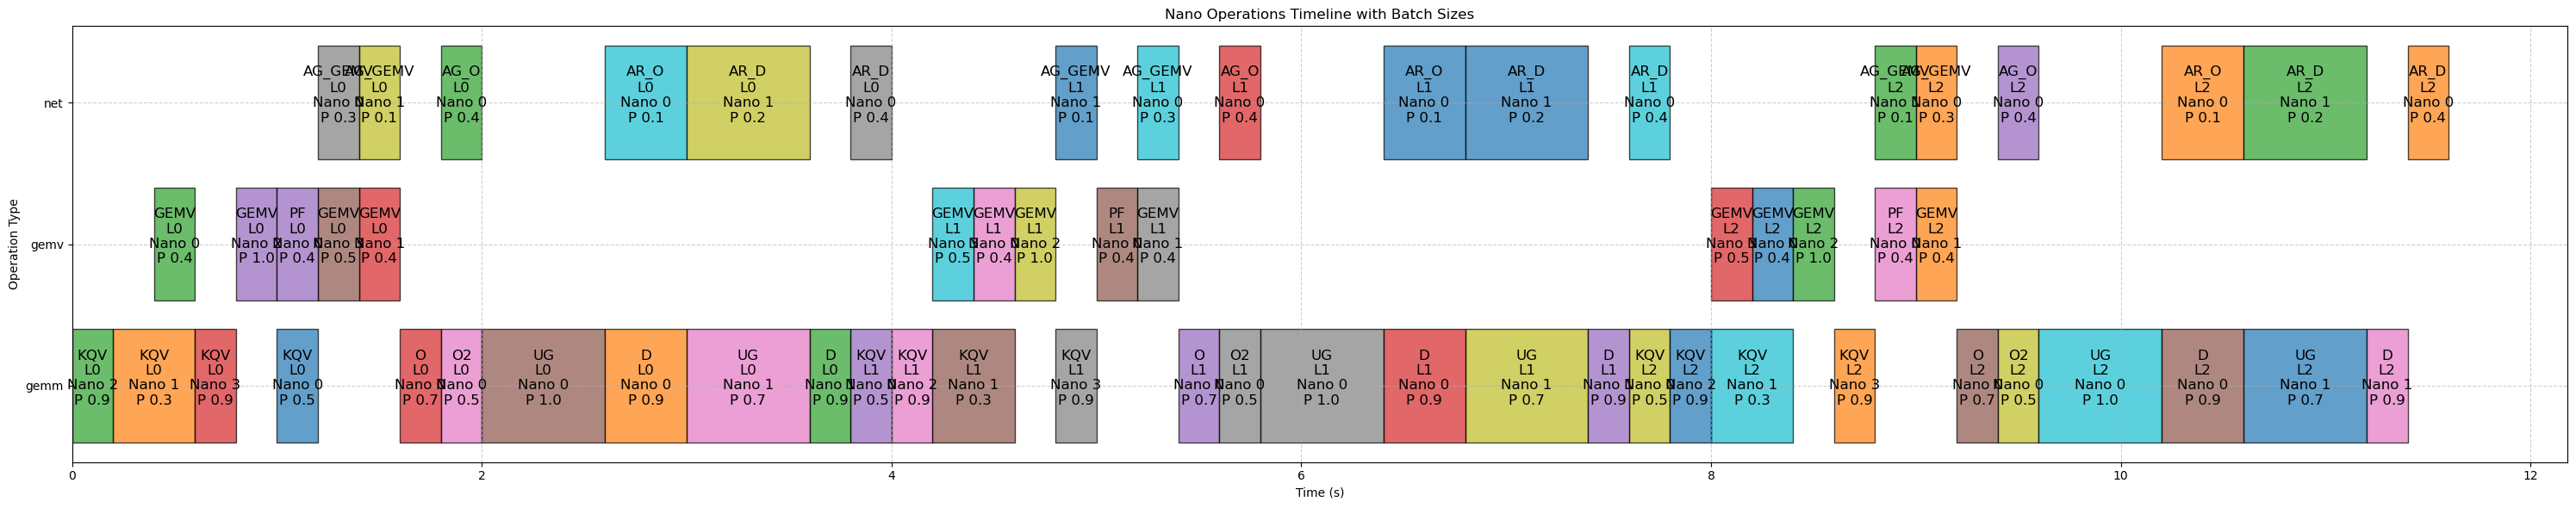

In [38]:
# again, plot the schedule
from matplotlib import pyplot as plt

# Assuming you have a list of NanoOperation instances called nano_operations_list
# and each NanoOperation has the required attributes.

# Extract unique operation types
operation_types = sorted(set(n.operation.category for n in second_stage_nano_ops))
y_positions = {op_type: i for i, op_type in enumerate(operation_types)}

fig, ax = plt.subplots(figsize=(30, 6))

for n in second_stage_nano_ops:
    n_name = n.name
    # Access the optimized values of the variables
    start_time = schedule[n]['start_time']
    duration = schedule[n]['duration']
    op_type = n.operation.category  # Assuming 'category
    p = schedule[n]['gpu_utilization']

    y_position = y_positions[op_type]
    
    # Plot the operation as a horizontal bar
    ax.barh(y_position, duration, left=start_time, height=0.8, alpha=0.7, edgecolor="black")
    
    # Annotate with operation name and batch size
    label = f"{n.operation.name}\nL{n.layered_operation.layer}\nNano {n.idx}\nP {p}\n"
    ax.text(start_time + duration / 2, y_position, label, ha="center", va="center", color="black", fontsize=12)
    
# Set y-ticks and labels
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Operation Type")
ax.set_title("Nano Operations Timeline with Batch Sizes")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("nano_operations_timeline_second_stage.png")
plt.show()

    

In [39]:
selected_sop = None
for sop in second_stage_nano_ops:
    if sop.name == "GEMV_2_0":
        selected_sop = sop
        break
print("start_time", schedule[selected_sop]['start_time'])
print("duration", schedule[selected_sop]['duration'])
print("finish_time", schedule[selected_sop]['finish_time'])
print("gpu_utilization", schedule[selected_sop]['gpu_utilization'])

# print isRunning variables
for p in selected_sop.p_choices:
    print(selected_sop.duration_units[p], selected_sop.p_vars[p].X)
    c = 0
    for t in range(100):
        if selected_sop.isrunning[p, t].X > 0.5:
            c += 1
            print(f"gpu utilization {p} at time {t} is running")
    print(f"gpu utilization {p} is running {c} times")


start_time 8.200000000000001
duration 0.2
finish_time 8.4
gpu_utilization 0.4
3 0.0
gpu utilization 0.1 is running 0 times
2 0.0
gpu utilization 0.2 is running 0 times
2 -0.0
gpu utilization 0.3 is running 0 times
1 1.0
gpu utilization 0.4 at time 41 is running
gpu utilization 0.4 is running 1 times
1 -0.0
gpu utilization 0.5 is running 0 times
1 -0.0
gpu utilization 0.6 is running 0 times
1 -0.0
gpu utilization 0.7 is running 0 times
1 -0.0
gpu utilization 0.8 is running 0 times
1 -0.0
gpu utilization 0.9 is running 0 times
1 -0.0
gpu utilization 1 is running 0 times


In [40]:
# Validate dependencies
print('\nValidating Dependencies:')
dependencies_satisfied = True
for op in second_stage_nano_ops:
    if op in schedule:
        op_start = schedule[op]['start_time']
        op_finish = schedule[op]['finish_time']
        for dep_op in op.depend_on_nano_ops:
            if dep_op in schedule:
                dep_finish = schedule[dep_op]['finish_time']
                if op_start < dep_finish - 1e-6:
                    dependencies_satisfied = False
                    print(f'Dependency violation: Operation {op.name} starts at {op_start}, '
                            f'but dependent operation {dep_op.name} finishes at {dep_finish}')
if dependencies_satisfied:
    print('All dependencies are satisfied.')

# Validate resource constraints
print('\nValidating Resource Constraints:')
resource_violation = False
# Collect all time points where operations start or finish
time_points = set()
for operation in schedule.values():
    time_points.add(operation['start_time'])
    time_points.add(operation['finish_time'])
# Create a sorted list of time points
time_points = sorted(time_points)
# Check resource utilization between each pair of time points
for i in range(len(time_points) - 1):
    interval_start = time_points[i]
    interval_end = time_points[i + 1]
    total_gpu_utilization = 0
    for operation in schedule.values():
        op_start = operation['start_time']
        op_finish = operation['finish_time']
        if op_start < interval_end - 1e-6 and op_finish > interval_start + 1e-6:
            total_gpu_utilization += operation['gpu_utilization']
    if total_gpu_utilization > 1.0 + 1e-6:
        resource_violation = True
        print(f'Resource violation between time {interval_start} and {interval_end}: '
                f'Total GPU utilization is {total_gpu_utilization} (> 1)')
if not resource_violation:
    print('Resource constraints are satisfied at all times.')

# --- End Validation ---


Validating Dependencies:
All dependencies are satisfied.

Validating Resource Constraints:
Resource constraints are satisfied at all times.
